# Análisis y Estrategia de Modelado

# Resumen del Dataset Preparado

Despue de haber aplicado el DATA_CLEANING (Data_Cleaning_housing.ipynb), el dataset (`housing_clean.csv`) ya contiene las siguientes características de alta calidad:

## Variables numéricas listas para modelar:
- `longitude`, `latitude` (coordenadas geográficas)
- `housing_median_age`
- `total_rooms_log`, `total_bedrooms_log`, `population_log` (transformaciones logarítmicas)
- `median_income_real` (ingreso medio normalizado a dólares)

## Variables de ratio (feature engineering muy potente):
- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`

## Variable categórica:
- `ocean_proximity`  
  (aunque ya se excluyó `<1H OCEAN`, debemos codificarla para los modelos)

## Variable objetivo:
- `median_house_value` (precio de la vivienda)  
  Ya se han limpiado los valores atípicos de `500,001`.

---

# ¿Por qué usar Random Forest y XGBoost?

Los modelos basados en árboles de decisión (Random Forest y XGBoost) son ideales para este caso por varias razones:

## 1. No linealidad
La relación entre el precio de una casa y características como la ubicación, el tamaño o los ingresos no es lineal.  
Los árboles capturan estas relaciones complejas de forma natural.

## 2. Robustez a la escala
A estos modelos no les afecta si las variables están transformadas (log) o no, ya que funcionan basándose en divisiones (*splits*) en los valores de las características, no en distancias euclidianas.

## 3. Manejo de interacciones
Pueden capturar automáticamente interacciones entre variables  
(ej. el efecto de `median_income` es muy diferente si `ocean_proximity` es `'NEAR BAY'` o `'INLAND'`).

## 4. Importancia de características
Proporcionan una forma clara de saber qué variables son más importantes para predecir el precio.

---

# Plan de Modelado

## 1. Preparación Final
- Codificar la variable `ocean_proximity` (usaremos One-Hot Encoding)

## 2. Separación de Datos
- Entrenamiento: 80%
- Prueba: 20%  
Para evaluar correctamente el rendimiento del modelo.

## 3. Selección de Modelos a Comparar
- **Línea Base (Regresión Lineal):**  
  Para tener un punto de comparación simple y ver cuánto mejoran los árboles.

- **Random Forest:**  
  Robustez y buen rendimiento por defecto.

- **XGBoost:**  
  Generalmente ofrece un rendimiento superior al Random Forest al ser una técnica de boosting más avanzada.

## 4. Optimización (si fuera necesario)
- Usar `GridSearchCV` para encontrar los mejores hiperparámetros de los modelos.

## 5. Evaluación
Comparar usando:
- **RMSE (Root Mean Squared Error):**  
  Nos dará el error típico en dólares.

- **R² (Coeficiente de Determinación):**  
  Indica qué porcentaje de la varianza del precio explica el modelo.

# --- CODIGO ---
## --- 1. Importación de librerías necesarias ---

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

## Para gráficos (opcional, muy útil para visualizar)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## --- 2. Carga y preparación inicial del dataset ---

In [7]:
df = pd.read_csv('../data/housing_clean.csv')

# Verificar valores nulos (no debería haber después de tu limpieza)
print("\nValores nulos por columna:\n", df.isnull().sum())

print("Dataset cargado (filas,columnas):", df.shape)

print("\nInfo del dataset:")
print(df.info())

print("\nPrimeras 5 filas:")
df.head()





Valores nulos por columna:
 longitude                   0
latitude                    0
ocean_proximity             0
housing_median_age          0
total_rooms_log             0
total_bedrooms_log          0
population_log              0
median_income_real          0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
median_house_value          0
dtype: int64
Dataset cargado (filas,columnas): (19670, 12)

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19670 entries, 0 to 19669
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 19670 non-null  float64
 1   latitude                  19670 non-null  float64
 2   ocean_proximity           19670 non-null  object 
 3   housing_median_age        19670 non-null  float64
 4   total_rooms_log           19670 non-null  float64
 5   total_bedrooms_log        19670 no

,longitude,latitude,ocean_proximity,housing_median_age,total_rooms_log,total_bedrooms_log,population_log,median_income_real,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
0,-122.23,37.88,NEAR BAY,41.0,6.781058,4.867534,5.777652,832520.0,6.984127,0.146591,2.555556,452600.0
1,-122.22,37.86,NEAR BAY,21.0,8.867850,7.009409,7.784057,830140.0,6.238137,0.155797,2.109842,358500.0
2,-122.24,37.85,NEAR BAY,52.0,7.291656,5.252273,6.208590,725740.0,8.288136,0.129516,2.802260,352100.0
3,-122.25,37.85,NEAR BAY,52.0,7.150701,5.463832,6.326149,564310.0,5.817352,0.184458,2.547945,341300.0
4,-122.25,37.85,NEAR BAY,52.0,7.395108,5.638355,6.338594,384620.0,6.281853,0.172096,2.181467,342200.0


## --- 3. Codificación de la variable 'ocean_proximity' ---
### Identificamos las columnas numéricas y la categórica

In [10]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'median_house_value' in numeric_features:
    numeric_features.remove('median_house_value')

categorical_features = ['ocean_proximity']  # Tu única categórica

# Creamos un preprocesador One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features), # Mantener las numéricas como están
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features) # Codificar la categórica
    ])


## --- 4. Separar en variables predictoras (X) y objetivo (y) ---

In [16]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

## --- 5. Dividir en conjuntos de entrenamiento y prueba ---

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

df.shape, X_train.shape, X_test.shape


Tamaño del conjunto de entrenamiento: (15736, 11)
Tamaño del conjunto de prueba: (3934, 11)


((19670, 12), (15736, 11), (3934, 11))

## --- 6. Definición y evaluación de los modelos ---
### Diccionario para guardar los pipelines de los modelos

In [29]:
models = {
    'Linear Regression': Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', LinearRegression())]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', RandomForestRegressor(n_estimators=100,
                                                                          random_state=42,
                                                                          n_jobs=-1))]),
    'XGBoost': Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(n_estimators=100,
                                                            learning_rate=0.1,
                                                            max_depth=5,
                                                            random_state=42))])
}

# Diccionario para almacenar los resultados
results = {}
best_model = None
best_rmse = float('inf')

print("\n--- Evaluación de Modelos ---")
for name, pipeline in models.items():
    print(f"\nEntrenando y evaluando {name}...")
    # Entrenar el modelo
    pipeline.fit(X_train, y_train)
    
    # Predecir sobre el conjunto de prueba
    y_pred = pipeline.predict(X_test)
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Guardar resultados
    results[name] = {'RMSE': rmse, 'R2': r2}
    
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R2 Score: {r2:.4f}")
    
    # Determinar el mejor modelo basado en el menor RMSE
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = name

print("\n" + "="*50)
print(f"*** MEJOR MODELO: {best_model} con un RMSE de ${best_rmse:,.2f} ***")
print("="*50)


--- Evaluación de Modelos ---

Entrenando y evaluando Linear Regression...
  RMSE: $59,571.14
  R2 Score: 0.6327

Entrenando y evaluando Random Forest...
  RMSE: $44,710.86
  R2 Score: 0.7931

Entrenando y evaluando XGBoost...
  RMSE: $42,939.84
  R2 Score: 0.8092

*** MEJOR MODELO: XGBoost con un RMSE de $42,939.84 ***


# --- 7. Optimización de hiperparámetros del mejor modelo ---

###  Busca la mejor combinación de hiperparámetros para XGBoost, lo que a menudo resulta en un modelo aún más preciso. Esto puede tardar, pero merece la pena. El código está configurado para un compromiso entre velocidad y efectividad (cv=3). Si tienes tiempo, cámbialo a cv=5.

# ¿Qué son los Hiperparámetros?

Primero, una distinción clave:

- **Parámetros del modelo:**  
  Son los valores que el modelo aprende por sí mismo durante el entrenamiento  
  (ej. los coeficientes de una regresión lineal, los pesos de una red neuronal).

- **Hiperparámetros:**  
  Son configuraciones que tú, como analista, debes definir **ANTES** de que el modelo comience a aprender  
  (ej. la profundidad de un árbol, la tasa de aprendizaje, el número de árboles).

---

# ¿Para qué sirve la Optimización de Hiperparámetros?

## 1. MEJORAR LA PRECISIÓN DEL MODELO

El propósito principal es encontrar la combinación perfecta de hiperparámetros que minimice el error de predicción (RMSE) y maximice el R².

**Ejemplo con XGBoost:**

- `max_depth=3` (árboles poco profundos) → **Subajuste (underfitting):**  
  el modelo es demasiado simple, no capta patrones complejos.

- `max_depth=15` (árboles muy profundos) → **Sobreajuste (overfitting):**  
  el modelo memoriza los datos de entrenamiento, pero falla en datos nuevos.

- `max_depth=6` (balanceado) → **Mejor generalización.**

La optimización encuentra ese "punto dulce" automáticamente.

---

## 2. EQUILIBRAR BIAS Y VARIANZA (Compensación)

- **Bajo bias + alta varianza:**  
  Modelo complejo que sobreajusta  
  (ej. árboles muy profundos, muchas características).

- **Alto bias + baja varianza:**  
  Modelo simple que subajusta  
  (ej. árboles muy pequeños, pocos estimadores).

Los hiperparámetros controlan este equilibrio:

- `n_estimators`: número de árboles (más árboles ↓ varianza)
- `max_depth`: profundidad del árbol (más profundidad ↓ bias, ↑ varianza)
- `learning_rate`: tasa de aprendizaje (más pequeña ↓ varianza, pero necesita más árboles)

---

## 3. EVITAR EL SOBREAJUSTE (Overfitting)

Hiperparámetros como `subsample` y `colsample_bytree` en XGBoost controlan el muestreo aleatorio de datos y características, lo que regulariza el modelo y evita que memorice ruido.

---

## 4. AUTOMATIZAR LA BÚSQUEDA DE LA MEJOR CONFIGURACIÓN

En lugar de probar manualmente combinaciones (lo que sería como encontrar una aguja en un pajar), `GridSearchCV` prueba todas las combinaciones posibles de manera sistemática y te dice cuál es la mejor.

In [30]:
print("\n--- Optimización de Hiperparámetros (GridSearchCV) para XGBoost ---")
# Nota: La optimización puede tomar varios minutos. Puedes omitirla si quieres rapidez.

# Definimos el pipeline solo para XGBoost
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(random_state=42,
                                                               objective='reg:squarederror'))])

# Definimos la grilla de parámetros a probar
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

# Configuramos el GridSearchCV (usa 3-5 folds, n_jobs=-1 para usar todos los núcleos)
# Nota: Aumentar cv a 5 puede ser más lento, pero más fiable.
grid_search = GridSearchCV(estimator=xgb_pipeline,
                           param_grid=param_grid,
                           cv=3,  # Reducimos a 3 folds para que sea más rápido. Puedes poner 5 si tienes tiempo.
                           scoring='neg_root_mean_squared_error', # Optimizamos en función del RMSE
                           verbose=1,
                           n_jobs=-1)

# Ejecutamos la búsqueda
grid_search.fit(X_train, y_train)

# Mejores parámetros y mejor modelo
print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
best_xgb = grid_search.best_estimator_

# Evaluamos el modelo optimizado en el conjunto de prueba
y_pred_best = best_xgb.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f"\n--- Evaluación del XGBoost Optimizado ---")
print(f"  RMSE: ${rmse_best:,.2f}")
print(f"  R2 Score: {r2_best:.4f}")

# Comparamos con el mejor modelo anterior (si XGBoost no era el mejor ya)
if rmse_best < best_rmse:
    print("\n*** El XGBoost optimizado es aún mejor que el modelo anterior! ***")
    best_model = "XGBoost Optimizado"
else:
    print(f"\nEl mejor modelo sigue siendo {best_model} con un RMSE de ${best_rmse:,.2f}")


--- Optimización de Hiperparámetros (GridSearchCV) para XGBoost ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Mejores parámetros encontrados: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 7, 'regressor__n_estimators': 300, 'regressor__subsample': 0.8}

--- Evaluación del XGBoost Optimizado ---
  RMSE: $40,355.86
  R2 Score: 0.8314

*** El XGBoost optimizado es aún mejor que el modelo anterior! ***


## --- 8. Análisis de la Importancia de Características ---

#### Es una técnica que mide y ordena qué variables (características) del dataset tienen mayor impacto en la predicción del modelo. En otras palabras, responde a la pregunta: "¿Qué factores realmente determinan el precio de una vivienda?"

## Obtenemos el mejor modelo entrenado (el optimizado si lo hicimos, si no, el del bucle)
### Elegimos usar el __XGBoost optimizado__ en vez del Random Forest porque ya  hicimos la optimización en el paso anterior.


--- Importancia de Características (XGBoost) ---
                       feature  importance
10      ocean_proximity_INLAND    0.600058
6           median_income_real    0.148485
9     population_per_household    0.042046
11    ocean_proximity_NEAR BAY    0.037864
12  ocean_proximity_NEAR OCEAN    0.029606
1                     latitude    0.028445
0                    longitude    0.026313
8            bedrooms_per_room    0.023190
7          rooms_per_household    0.018603
2           housing_median_age    0.017124
4           total_bedrooms_log    0.009980
5               population_log    0.009315
3              total_rooms_log    0.008971


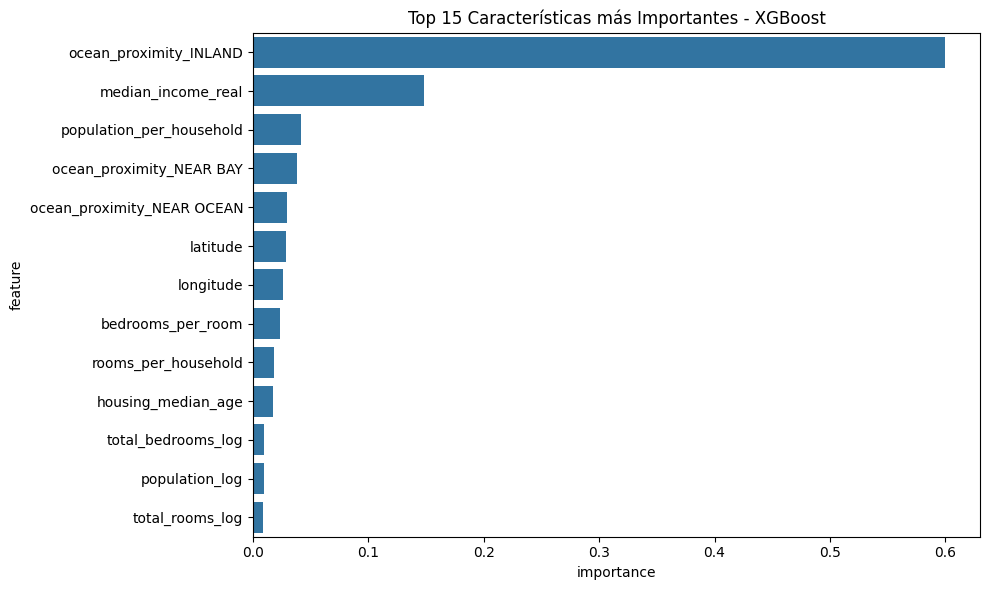


--- Análisis completado ---


In [ ]:
if 'best_xgb' in locals():
    final_model = best_xgb
    model_type = "XGBoost"
else:
    final_model = models[best_model]
    model_type = best_model

# Extraemos el regressor del pipeline
if hasattr(final_model, 'named_steps'):
    regressor = final_model.named_steps['regressor']
else:
    regressor = final_model

# Obtenemos la importancia de características si el modelo lo permite
if hasattr(regressor, 'feature_importances_'):
    # Necesitamos obtener los nombres de las características después del preprocesamiento
    # Ajustamos el preprocesador a todo el conjunto X para obtener los nombres
    preprocessor.fit(X)
    feature_names = (numeric_features + 
                     list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))
    
    importances = regressor.feature_importances_
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

    print(f"\n--- Importancia de Características ({model_type}) ---")
    print(feature_importance_df.head(15))  # Mostrar las 15 más importantes

    # Gráfico de barras
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature')
    plt.title(f'Top 15 Características más Importantes - {model_type}')
    plt.tight_layout()
    plt.show()
else:
    print("El modelo seleccionado no proporciona importancia de características de forma directa.")

print("\n--- Análisis completado ---")

# Conclusiones e Insights más Relevantes

## 1. Factor dominante: ubicación interior vs. costa

- `ocean_proximity_INLAND` tiene una importancia de **0.58**, más del doble que cualquier otra variable.

**Insight:**  
La principal diferenciadora del precio de una vivienda es si está en el interior (`INLAND`) o no.  
Estar en el interior reduce fuertemente el valor predicho (dependiendo de la codificación del modelo, pero generalmente se asocia a menor precio).

**Conclusión práctica:**  
En este mercado, la cercanía al mar es el factor más determinante; lejos de la costa, otras variables pierden relevancia relativa.

---

## 2. Ingreso medio del hogar, segundo factor relevante

- `median_income_real` = **0.12**

**Insight:**  
El ingreso sigue siendo importante, pero mucho menos que la localización interior/costa.

**Conclusión práctica:**  
Si ya sabemos que una casa no está en `INLAND` (es decir, está cerca de la bahía o el océano), el ingreso del área ayuda a ajustar el precio, pero no revierte el efecto de estar tierra adentro.

---

## 3. Variables con impacto bajo (0.01 – 0.05)

- `population_per_household` (**0.05**) → leve efecto
- `ocean_proximity_NEAR BAY` (**0.04**)  
- `ocean_proximity_NEAR OCEAN` (**0.03**) → mucho menos influyentes que `INLAND`
- `latitude`, `longitude` (**0.01–0.02**) → casi irrelevantes
- Otras variables (habitaciones, antigüedad, logs, etc.) → alrededor de **0.01**

**Insight clave:**  
Muchas variables comúnmente usadas en modelos de precios de vivienda (número de cuartos, antigüedad, tamaño de población) aportan muy poca ganancia predictiva una vez que se controla por ubicación (`INLAND` vs costa) e ingreso.

---

## 4. Implicaciones para el modelado y el negocio

| Propósito                | Conclusión |
|-------------------------|------------|
| Mejora del modelo       | Se podrían eliminar variables con importancia < 0.02 (`latitude`, `longitude`, `bedrooms_per_room`, etc.) sin pérdida significativa, simplificando el modelo. |
| Interpretación de negocio | Invertir en propiedades costeras o cercanas a la bahía tiene mucho mayor retorno que mejorar características internas de viviendas en el interior. |
| Política pública        | Las zonas `INLAND` necesitan incentivos adicionales (transporte, servicios), ya que el mercado las penaliza frente a zonas costeras. |

---

## 5. Posible limitación del análisis

- La alta importancia de `INLAND` podría deberse a:
  - Desequilibrio de clases (más viviendas en interior que en costa)
  - Interacciones no capturadas

**Recomendación:**  
Validar con técnicas como:
- SHAP
- PDP (Partial Dependence Plots)

para comprobar si la relación es lineal o presenta umbrales.

---

# Resumen Ejecutivo

**“La localización interior (`INLAND`) explica más de la mitad de la varianza predicha.  
El ingreso medio es un factor secundario.  
El resto de variables aporta muy poco valor predictivo adicional.”**